<a href="https://colab.research.google.com/github/jahidurmahim/Machine_Learning_Laboratory/blob/main/BackPropagation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Import Libraries

In [246]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

## Install Libraries

In [247]:
pip install ucimlrepo

## Load Data

In [248]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
iris = fetch_ucirepo(id=53)

# data (as pandas dataframes)
X = iris.data.features
y = iris.data.targets

# metadata
print(iris.metadata)

# variable information
print(iris.variables)

{'uci_id': 53, 'name': 'Iris', 'repository_url': 'https://archive.ics.uci.edu/dataset/53/iris', 'data_url': 'https://archive.ics.uci.edu/static/public/53/data.csv', 'abstract': 'A small classic dataset from Fisher, 1936. One of the earliest known datasets used for evaluating classification methods.\n', 'area': 'Biology', 'tasks': ['Classification'], 'characteristics': ['Tabular'], 'num_instances': 150, 'num_features': 4, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1936, 'last_updated': 'Tue Sep 12 2023', 'dataset_doi': '10.24432/C56C76', 'creators': ['R. A. Fisher'], 'intro_paper': {'ID': 191, 'type': 'NATIVE', 'title': 'The Iris data set: In search of the source of virginica', 'authors': 'A. Unwin, K. Kleinman', 'venue': 'Significance, 2021', 'year': 2021, 'journal': 'Significance, 2021', 'DOI': '1740-9713.01589', 'URL': 'https://www.semanticscholar.org

## Combine Features and Target

In [249]:
df = pd.concat([X, y], axis=1)
df.head()

,sepal length,sepal width,petal length,petal width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


## Check DataFrame Shape

In [250]:
df.shape

(150, 5)

## Check for Missing Values

In [251]:
df.isna().sum().T

,0
sepal length,0
sepal width,0
petal length,0
petal width,0
class,0


## Check for Duplicate Rows

In [252]:
df.duplicated().sum()

np.int64(3)

## Identify Outliers

In [253]:
outlier_summary = []

numeric_cols = df.select_dtypes(include='number').columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_count = ((df[col] < lower) | (df[col] > upper)).sum()

    if outlier_count > 0:
        outlier_summary.append({
            'feature': col,
            'Q1': Q1,
            'Q3': Q3,
            'lower_bound': lower,
            'upper_bound': upper,
            'outlier_count': outlier_count
        })

outlier_df = pd.DataFrame(outlier_summary)
outlier_df

,feature,Q1,Q3,lower_bound,upper_bound,outlier_count
0,sepal width,2.8,3.3,2.05,4.05,4


## Visualize Outliers with Box Plots

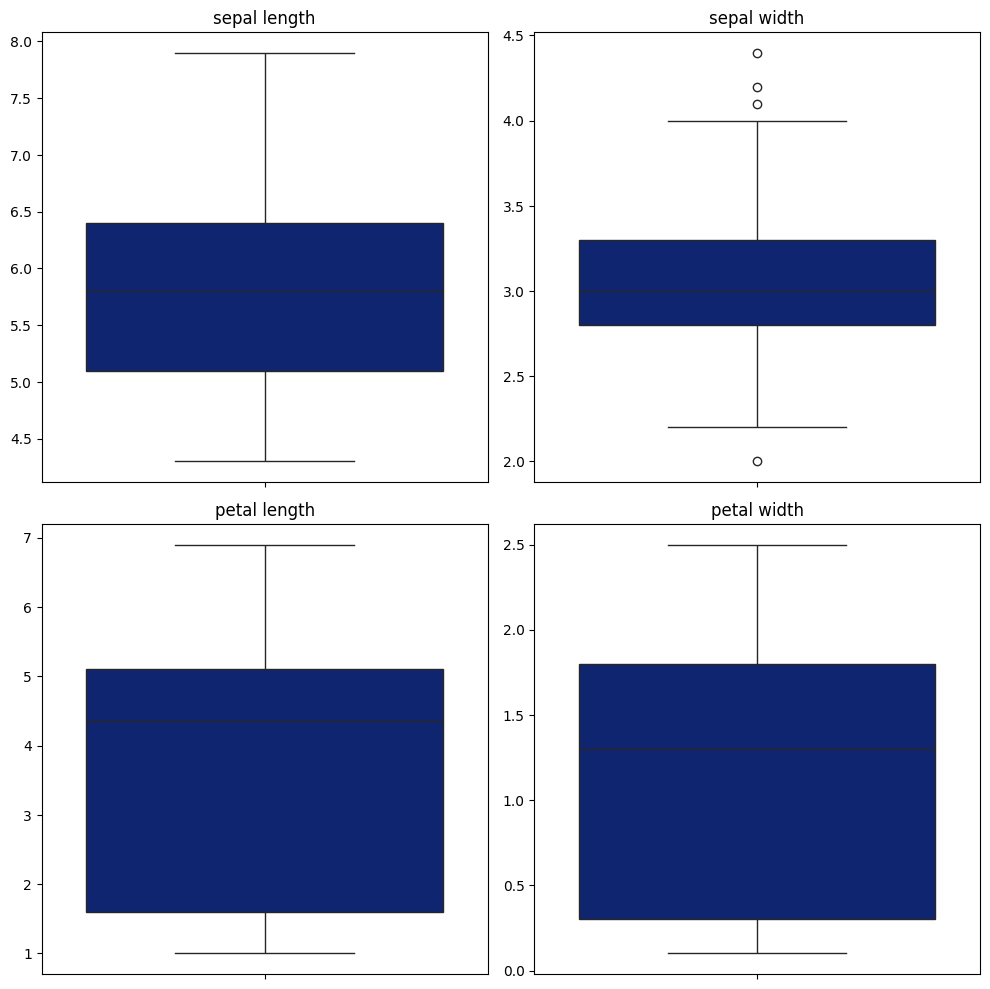

In [254]:
numeric_features = df.select_dtypes(include='number').columns.tolist()

rows = (len(numeric_features) + 1) // 2  # Adjust rows dynamically
cols = 2  # Set columns to 2 for better layout
fig, axes = plt.subplots(rows, cols, figsize=(10, 5 * rows))

axes = axes.flatten()

for i, feature in enumerate(numeric_features):
    sns.boxplot(y=df[feature], ax=axes[i])
    axes[i].set_title(feature)
    axes[i].set_ylabel('')

# Remove any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Prepare for Outlier Capping

In [255]:
capped_summary = []

numeric_features = df.select_dtypes(include='number').columns.tolist()

for feature in numeric_features:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    capped_summary.append([feature, Q1, Q3, lower, upper, 0])

capped_df = pd.DataFrame(capped_summary, columns=['feature','Q1','Q3','lower_bound','upper_bound','outlier_count'])

display(capped_df)

,feature,Q1,Q3,lower_bound,upper_bound,outlier_count
0,sepal length,5.1,6.4,3.15,8.35,0
1,sepal width,2.8,3.3,2.05,4.05,0
2,petal length,1.6,5.1,-3.65,10.35,0
3,petal width,0.3,1.8,-1.95,4.05,0


## Apply Outlier Capping and Visualize

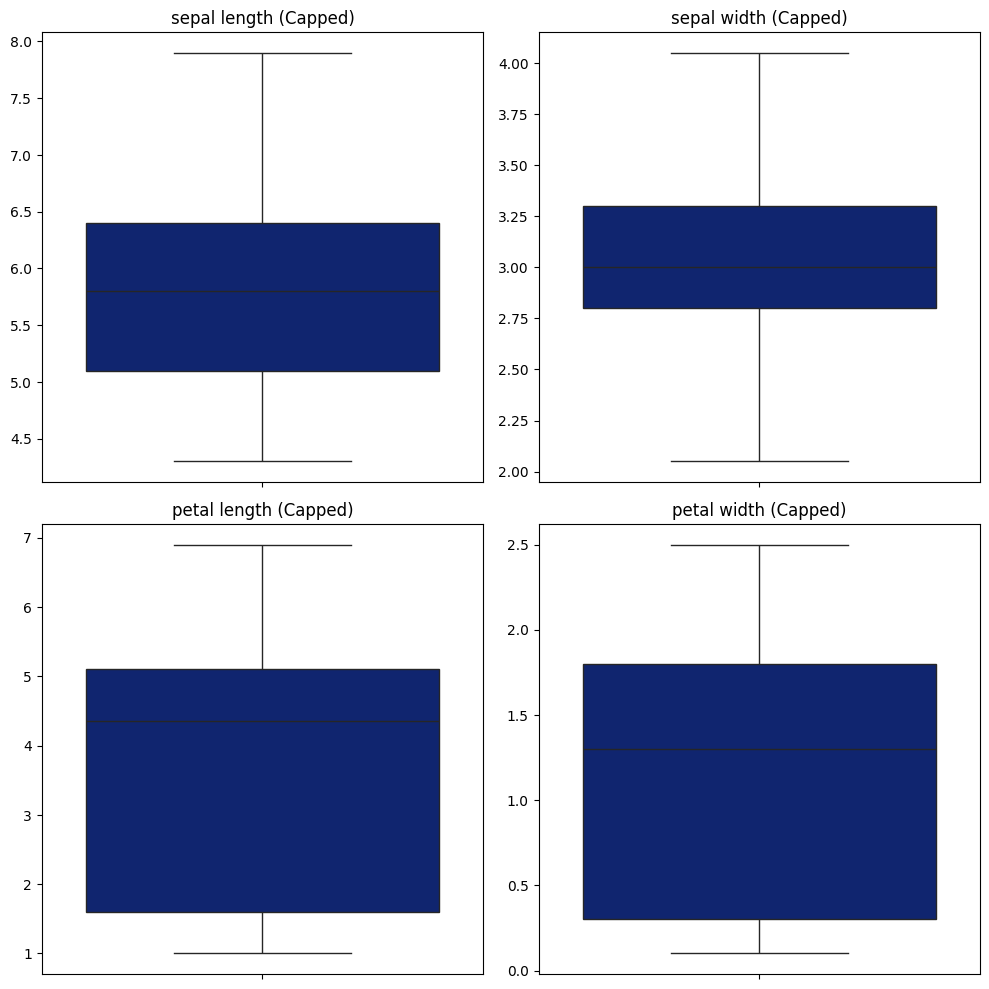

In [256]:
df_capped = df.copy()

for feature in numeric_features:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_capped[feature] = df_capped[feature].clip(lower=lower, upper=upper)

numeric_features_capped = df_capped.select_dtypes(include='number').columns.tolist()

rows_capped = (len(numeric_features_capped) + 1) // 2
cols_capped = 2
fig_capped, axes_capped = plt.subplots(rows_capped, cols_capped, figsize=(10, 5 * rows_capped))

axes_capped = axes_capped.flatten()

for i, feature in enumerate(numeric_features_capped):
    sns.boxplot(y=df_capped[feature], ax=axes_capped[i])
    axes_capped[i].set_title(f'{feature} (Capped)')
    axes_capped[i].set_ylabel('')

for j in range(i + 1, len(axes_capped)):
    fig_capped.delaxes(axes_capped[j])

plt.tight_layout()
plt.show()

## Separate Features and Target

In [257]:
X = df.drop("class", axis=1).values
y = df["class"].values.reshape(-1, 1)

print(X.shape)
print(y.shape)

(150, 4)
(150, 1)


## Standardize Features

In [258]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

## Split Data into Training and Testing Sets

In [259]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape)
print(X_test.shape)

(120, 4)
(30, 4)


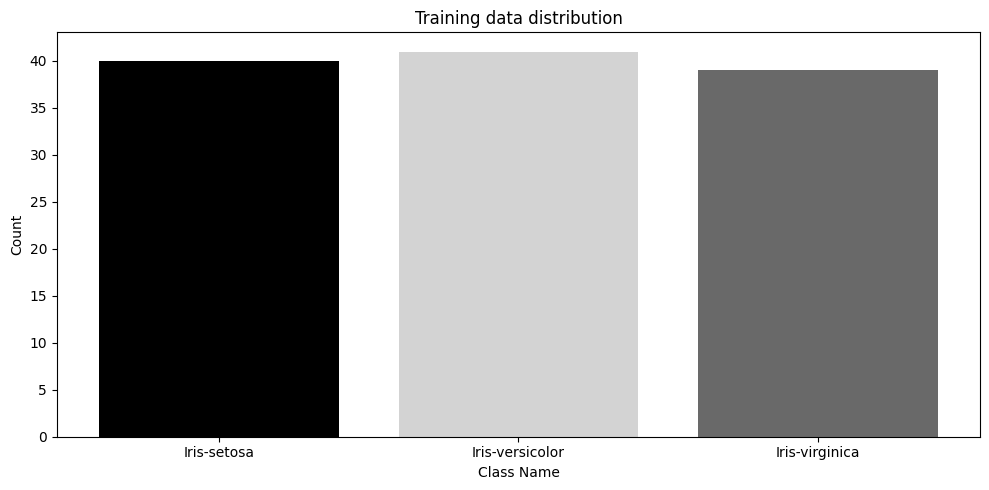

In [262]:
iris = fetch_ucirepo(id=53)
X_initial = iris.data.features
y_initial = iris.data.targets

# Combine Features and Target
df = pd.concat([X_initial, y_initial], axis=1)

# Separate Features and Target
X = df.drop("class", axis=1).values
y = df["class"].values.reshape(-1, 1)

# Standardize Features
scaler = StandardScaler()
X = scaler.fit_transform(X)
# --- End Data Loading and Preprocessing ---

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

def plot_labels_distribution(data_labels):
    # Flatten the labels if they are in a column vector format
    if data_labels.ndim > 1:
        data_labels = data_labels.flatten()

    # Encode string labels to numerical labels
    le = LabelEncoder()
    encoded_labels = le.fit_transform(data_labels)
    class_names = le.classes_

    counts = np.bincount(encoded_labels)

    plt.style.use('seaborn-v0_8-dark-palette') # Updated style for modern matplotlib

    fig, ax = plt.subplots(figsize=(10,5))
    # Use three distinct colors for the bars
    colors = ['black', 'lightgrey', 'dimgrey'] # Black for Iris-setosa, Light Grey for Iris-versicolor, Dim Grey for Iris-virginica
    ax.bar(range(len(counts)), counts, width=0.8, align='center', color=colors[:len(counts)])
    ax.set(xticks=range(len(counts)), xticklabels=class_names, title='Training data distribution')
    ax.set_xlabel('Class Name')
    ax.set_ylabel('Count')

    plt.tight_layout()
    plt.show()

# Call the function with y_train
plot_labels_distribution(y_train)

In [263]:
from sklearn.preprocessing import LabelEncoder
from keras.utils import to_categorical

# Initialize LabelEncoder
le = LabelEncoder()

# Fit and transform y_train and y_test
y_train_encoded = le.fit_transform(y_train.flatten())
y_test_encoded = le.transform(y_test.flatten())

# One-hot encode the labels
y_train_one_hot = to_categorical(y_train_encoded)
y_test_one_hot = to_categorical(y_test_encoded)

print("Shape of y_train_one_hot:", y_train_one_hot.shape)
print("Shape of y_test_one_hot:", y_test_one_hot.shape)

Shape of y_train_one_hot: (120, 3)
Shape of y_test_one_hot: (30, 3)


In [264]:
print('Shapes of the prepared data for model training:')
print(f'X_train shape: {X_train.shape}')
print(f'y_train_one_hot shape: {y_train_one_hot.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_test_one_hot shape: {y_test_one_hot.shape}')

Shapes of the prepared data for model training:
X_train shape: (120, 4)
y_train_one_hot shape: (120, 3)
X_test shape: (30, 4)
y_test_one_hot shape: (30, 3)


In [265]:
print("Training data")
print(f"- Maximum Value {X_train.max()} ")
print(f"- Minimum Value {X_train.min()} ")

print("\n")

print("Testing data")
print(f"- Maximum Value {X_test.max()} ")
print(f"- Minimum Value {X_test.min()} ")

Training data
- Maximum Value 3.1146839106774356 
- Minimum Value -2.438987252491841 


Testing data
- Maximum Value 2.4920192021244283 
- Minimum Value -1.9761813222277342 


In [266]:
display(y_test_one_hot)

array([[0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [1., 0., 0.],
       [1., 0., 0.]])

## Import Keras Modules

In [267]:
from keras import models
from keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Based on X_train.shape (120, 4), input features are 4.
# Based on y_train_one_hot.shape (120, 3), there are 3 unique labels.
input_features = 4
nb_unique_labels = 3

def define_network_architecture():
    network = Sequential()
    # Input layer: 4 features, 16 neurons for a small dataset
    network.add(Dense(16, activation='sigmoid', input_shape=(input_features,)))
    # Hidden layer: 8 neurons
    network.add(Dense(8, activation='sigmoid'))
    # Output layer: 3 classes, softmax activation for multi-class classification
    network.add(Dense(nb_unique_labels, activation='softmax'))
    return network

# Ensure the network is defined before compiling
network = define_network_architecture()
network.compile(optimizer='rmsprop',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Define Neural Network Architecture

In [299]:
# Based on X_train.shape (120, 4), input features are 4.
# Based on y_train_one_hot.shape (120, 3), there are 3 unique labels.
input_features = 4
nb_unique_labels = 3

def define_network_architecture():
    network = Sequential()
    # Input layer: 4 features, 16 neurons for a small dataset
    network.add(Dense(16, activation='sigmoid', input_shape=(input_features,)))
    # Hidden layer: 8 neurons
    network.add(Dense(8, activation='sigmoid'))
    # Output layer: 3 classes, softmax activation for multi-class classification
    network.add(Dense(nb_unique_labels, activation='softmax'))
    return network

## Display Model Summary

In [269]:
network = define_network_architecture()
network.summary()

Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_57 (Dense)                │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_58 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_59 (Dense)                │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 243 (972.00 B)

 Trainable params: 243 (972.00 B)

 Non-trainable params: 0 (0.00 B)

## Evaluate Model (First Run)

In [270]:
network.compile(optimizer='rmsprop',
              loss='categorical_crossentropy',
              metrics=['accuracy'])
history = network.fit(X_train, y_train_one_hot, epochs=100, batch_size=1)

Epoch 1/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.6167 - loss: 0.8849
Epoch 2/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6583 - loss: 0.6431
Epoch 3/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6667 - loss: 0.5028
Epoch 4/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7250 - loss: 0.4153
Epoch 5/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8500 - loss: 0.3471
Epoch 6/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9417 - loss: 0.2869
Epoch 7/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9417 - loss: 0.2446
Epoch 8/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9500 - loss: 0.2113
Epoch 9/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9583 - loss: 0.1886
Epoch 10/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9500 - loss: 0.1699
Epoch 11/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9583 - loss: 0.1558
Epoch 12/100
120/120 ━━━━━━━━━━━━━━━━━━━━

## Compile and Train Model (First Run)

In [271]:
test_loss, test_accuracy = network.evaluate(X_test, y_test_one_hot)
print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_accuracy:.4f}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - accuracy: 1.0000 - loss: 0.0226
Test Loss: 0.0226
Test Accuracy: 1.0000


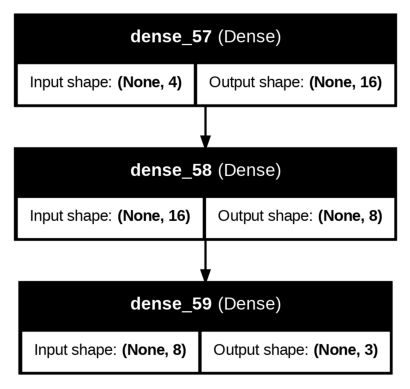

In [272]:
!pip install pydot graphviz

from tensorflow.keras.utils import plot_model

import matplotlib.image as mpimg
import matplotlib.pyplot as plt

plot_model(network, to_file='network_architecture.png', show_shapes=True, show_layer_names=True)

img = mpimg.imread('network_architecture.png')
plt.imshow(img)
plt.axis('off')
plt.show()

## Recompile Model

In [273]:
network.compile(optimizer='rmsprop',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

## Train Model with Validation Split

In [274]:
# Fit the model
batch_size = 256
n_epochs = 15
val_split = 0.2
patience_value = 5

# Fit the model with the callback
history = network.fit(X_train, y_train_one_hot, validation_split=val_split,
        	epochs=n_epochs, batch_size=batch_size)

Epoch 1/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.9792 - loss: 0.0557 - val_accuracy: 0.9583 - val_loss: 0.0404
Epoch 2/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step - accuracy: 0.9792 - loss: 0.0536 - val_accuracy: 0.9583 - val_loss: 0.0347
Epoch 3/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step - accuracy: 0.9792 - loss: 0.0531 - val_accuracy: 1.0000 - val_loss: 0.0333
Epoch 4/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.9792 - loss: 0.0527 - val_accuracy: 1.0000 - val_loss: 0.0318
Epoch 5/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.9792 - loss: 0.0524 - val_accuracy: 1.0000 - val_loss: 0.0307
Epoch 6/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step - accuracy: 0.9792 - loss: 0.0521 - val_accuracy: 1.0000 - val_loss: 0.0298
Epoch 7/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 548ms/step - accuracy: 0.9792 - loss: 0.0519 - val_accuracy: 1.0000 - val_loss: 0.0296
Epoch 8/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step - accuracy: 0.9792 - loss: 0.0517 - val_accuracy: 1.0000 - val_loss: 0.0

## Plot Training and Validation Accuracy

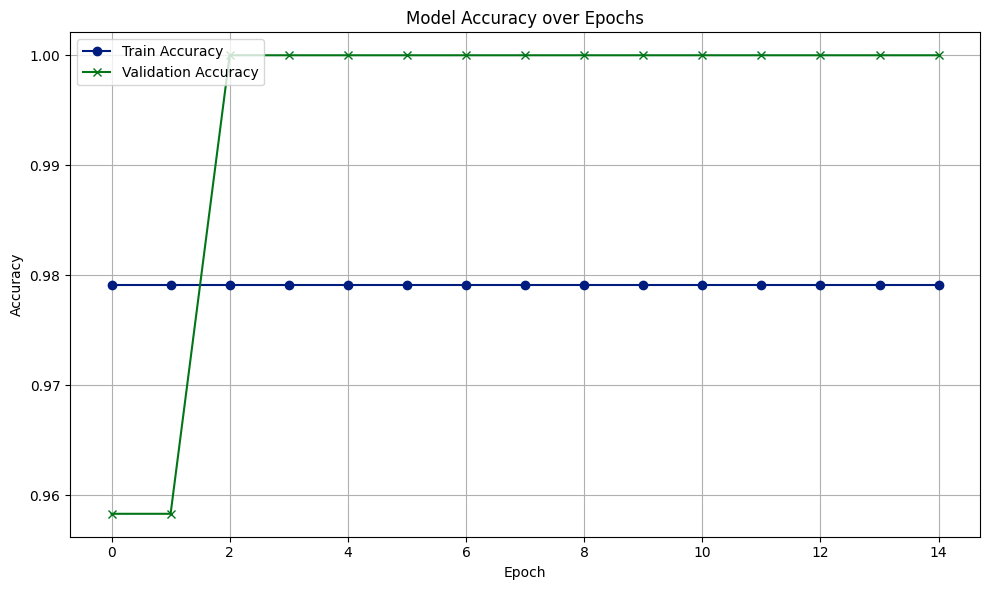

In [275]:
plt.figure(figsize=(10, 6)) # Increased figure size
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o') # Added label and marker
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='x') # Added label and marker
plt.title('Model Accuracy over Epochs') # Improved title
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.grid(True) # Added grid
plt.tight_layout() # Ensure layout is tight
plt.show()

## Plot Training and Validation Loss

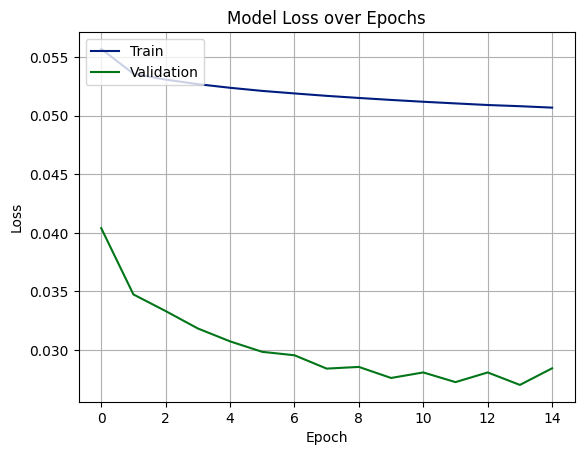

In [276]:

# Plot training & validation loss values
plt.subplot(1, 1, 1)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss over Epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True)

## Evaluate Model (Second Run)

In [277]:
loss, acc = network.evaluate(X_test,
                         	y_test_one_hot, batch_size=batch_size)

print("\nTest accuracy: %.1f%%" % (100.0 * acc))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 1.0000 - loss: 0.0113

Test accuracy: 100.0%


## Train Model with TensorFlow (Keras API)

In [278]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Define the network architecture
def create_tf_model():
    model = Sequential()
    model.add(Dense(16, activation='relu', input_shape=(X_train.shape[1],)))
    model.add(Dense(8, activation='relu'))
    model.add(Dense(y_train_one_hot.shape[1], activation='softmax'))
    return model

# Create and compile the model
tf_model = create_tf_model()
tf_model.compile(optimizer='rmsprop',
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])

tf_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_60 (Dense)                │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_61 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_62 (Dense)                │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 243 (972.00 B)

 Trainable params: 243 (972.00 B)

 Non-trainable params: 0 (0.00 B)

In [298]:
# Train the TensorFlow model
tf_history = tf_model.fit(X_train, y_train_one_hot, epochs=100, batch_size=1, verbose=0)

# Evaluate the model on the test set
tf_loss, tf_accuracy = tf_model.evaluate(X_test, y_test_one_hot, verbose=0)

print(f'TensorFlow Model Test Loss: {100.0 * tf_loss:2.2f}%')
print(f'TensorFlow Model Test Accuracy: {100.0 * tf_accuracy:2.2f}%')

TensorFlow Model Test Loss: 0.45%
TensorFlow Model Test Accuracy: 100.00%


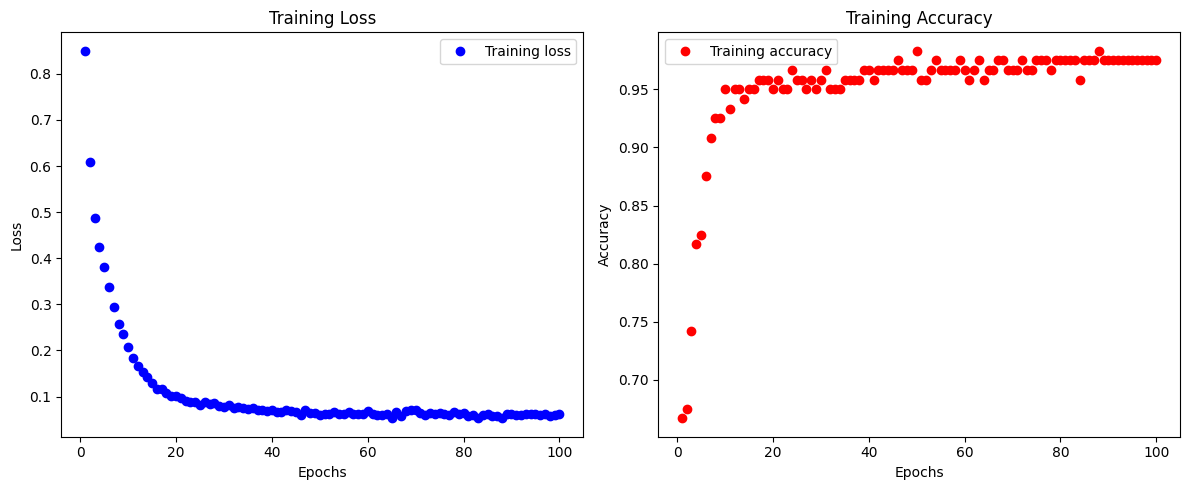

In [280]:
import matplotlib.pyplot as plt

# Plot training history (loss and accuracy)
history_dict = tf_history.history
loss_values = history_dict['loss']
acc_values = history_dict['accuracy']
epochs = range(1, len(loss_values) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, loss_values, 'bo', label='Training loss')
plt.title('Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, acc_values, 'ro', label='Training accuracy')
plt.title('Training Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

## Train Model with PyTorch

In [281]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Convert numpy arrays to PyTorch tensors
X_train_pt = torch.tensor(X_train, dtype=torch.float32)
y_train_pt = torch.tensor(y_train_one_hot, dtype=torch.float32)
X_test_pt = torch.tensor(X_test, dtype=torch.float32)
y_test_pt = torch.tensor(y_test_one_hot, dtype=torch.float32)

# Create TensorDatasets
train_dataset = TensorDataset(X_train_pt, y_train_pt)
test_dataset = TensorDataset(X_test_pt, y_test_pt)

# Create DataLoaders
batch_size = 32 # Using a small batch size for this small dataset
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Define the neural network architecture
class IrisNet(nn.Module):
    def __init__(self, input_size, hidden_size_1, hidden_size_2, num_classes):
        super(IrisNet, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size_1)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size_1, hidden_size_2)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(hidden_size_2, num_classes)

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu1(out)
        out = self.fc2(out)
        out = self.relu2(out)
        out = self.fc3(out)
        return out

# Hyperparameters
input_size_pt = X_train.shape[1]
hidden_size_1_pt = 16
hidden_size_2_pt = 8
num_classes_pt = y_train_one_hot.shape[1]
learning_rate_pt = 0.01
num_epochs_pt = 100

# Instantiate the model
pt_model = IrisNet(input_size_pt, hidden_size_1_pt, hidden_size_2_pt, num_classes_pt)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(pt_model.parameters(), lr=learning_rate_pt)

print("PyTorch model and data loaders initialized.")

PyTorch model and data loaders initialized.


In [282]:
# Train the PyTorch model
pt_model.train() # Set the model to training mode

for epoch in range(num_epochs_pt):
    for i, (inputs, labels) in enumerate(train_loader):
        # Forward pass
        outputs = pt_model(inputs)
        loss = criterion(outputs, labels)

        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs_pt}], Loss: {loss.item():.4f}')

print("PyTorch training complete.")

Epoch [10/100], Loss: 0.2842
Epoch [20/100], Loss: 0.0602
Epoch [30/100], Loss: 0.0786
Epoch [40/100], Loss: 0.0399
Epoch [50/100], Loss: 0.0644
Epoch [60/100], Loss: 0.0833
Epoch [70/100], Loss: 0.0180
Epoch [80/100], Loss: 0.0237
Epoch [90/100], Loss: 0.0328
Epoch [100/100], Loss: 0.1085
PyTorch training complete.


In [295]:
# Evaluate the PyTorch model
pt_model.eval() # Set the model to evaluation mode

with torch.no_grad(): # Disable gradient calculation during evaluation
    correct = 0
    total = 0
    for inputs, labels in test_loader:
        outputs = pt_model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        _, true_labels_indices = torch.max(labels.data, 1)
        total += labels.size(0)
        correct += (predicted == true_labels_indices).sum().item()

    pt_accuracy = correct / total
    print(f'PyTorch Model Test Accuracy: {pt_accuracy:2.2f}%')

    # Calculate test loss (optional, as CrossEntropyLoss takes class indices)
    # To get loss on test set, we need to manually compute it for one-hot labels
    test_outputs = pt_model(X_test_pt)
    pt_test_loss = criterion(test_outputs, y_test_pt).item()
    print(f'PyTorch Model Test Loss: {100.0 * pt_test_loss:2.2f}%')

PyTorch Model Test Accuracy: 1.00%
PyTorch Model Test Loss: 0.96%


## PyTorch Model Test Performance Comparison

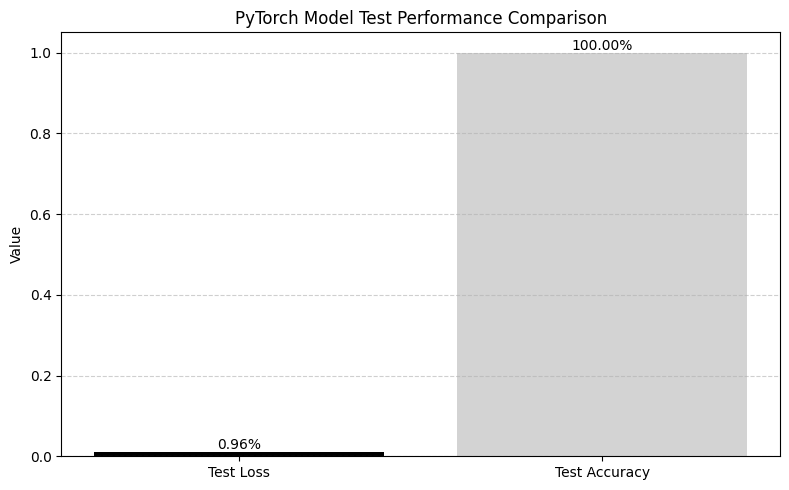

In [284]:
import matplotlib.pyplot as plt

metrics = ['Test Loss', 'Test Accuracy']
values = [pt_test_loss, pt_accuracy]

plt.figure(figsize=(8, 5))
# Use plt.bar to create a bar chart for the comparison
colors = ['black', 'lightgrey'] # Use black and grey colors
plt.bar(metrics, values, color=colors)
plt.ylabel('Value')
plt.title('PyTorch Model Test Performance Comparison')
plt.ylim(bottom=0) # Set y-axis lower limit to 0

# Add text labels on top of the bars
for i, value in enumerate(values):
    # Format as percentage with 2 decimal places
    plt.text(metrics[i], value, f'{value * 100:.2f}%', ha='center', va='bottom', fontsize=10, color='black')

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Train Model with NumPy (from scratch)

In [285]:
# Define the neural network architecture parameters
input_size = X_train.shape[1] # 4 features
hidden_size_1 = 16 # First hidden layer
hidden_size_2 = 8  # Second hidden layer
output_size = y_train_one_hot.shape[1] # 3 classes

# Initialize weights and biases randomly
# Weights for input to first hidden layer
W1 = np.random.randn(input_size, hidden_size_1) * 0.01
b1 = np.zeros((1, hidden_size_1))

# Weights for first hidden layer to second hidden layer
W2 = np.random.randn(hidden_size_1, hidden_size_2) * 0.01
b2 = np.zeros((1, hidden_size_2))

# Weights for second hidden layer to output layer
W3 = np.random.randn(hidden_size_2, output_size) * 0.01
b3 = np.zeros((1, output_size))

print("Weights and biases initialized.")

Weights and biases initialized.


In [286]:
# Activation functions
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)

def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True)) # for numerical stability
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

# Loss function
def categorical_crossentropy(predictions, targets):
    num_samples = predictions.shape[0]
    # Clip predictions to avoid log(0)
    predictions = np.clip(predictions, 1e-12, 1. - 1e-12)
    loss = -np.sum(targets * np.log(predictions)) / num_samples
    return loss

print("Activation and loss functions defined.")

Activation and loss functions defined.


In [287]:
# Training parameters
epochs = 100
learning_rate = 0.01

# Store loss and accuracy for plotting
history = {'loss': [], 'accuracy': []}

for epoch in range(epochs):
    # Forward propagation
    # Layer 1
    Z1 = np.dot(X_train, W1) + b1
    A1 = sigmoid(Z1)

    # Layer 2
    Z2 = np.dot(A1, W2) + b2
    A2 = sigmoid(Z2)

    # Output Layer
    Z3 = np.dot(A2, W3) + b3
    A3 = softmax(Z3)

    # Calculate loss
    loss = categorical_crossentropy(A3, y_train_one_hot)
    history['loss'].append(loss)

    # Calculate accuracy
    predictions = np.argmax(A3, axis=1)
    true_labels = np.argmax(y_train_one_hot, axis=1)
    accuracy = np.mean(predictions == true_labels)
    history['accuracy'].append(accuracy)

    # Backpropagation
    # Output Layer
    dZ3 = A3 - y_train_one_hot # Derivative of softmax and cross-entropy loss
    dW3 = np.dot(A2.T, dZ3)
    db3 = np.sum(dZ3, axis=0, keepdims=True)

    # Layer 2
    dA2 = np.dot(dZ3, W3.T)
    dZ2 = dA2 * sigmoid_derivative(Z2)
    dW2 = np.dot(A1.T, dZ2)
    db2 = np.sum(dZ2, axis=0, keepdims=True)

    # Layer 1
    dA1 = np.dot(dZ2, W2.T)
    dZ1 = dA1 * sigmoid_derivative(Z1)
    dW1 = np.dot(X_train.T, dZ1)
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    # Update weights and biases
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2
    W3 -= learning_rate * dW3
    b3 -= learning_rate * db3

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch + 1}/{epochs}, Loss: {loss:.4f}, Accuracy: {accuracy:.4f}')

print("Training complete for NumPy model.")

Epoch 10/100, Loss: 1.0984, Accuracy: 0.3417
Epoch 20/100, Loss: 1.0984, Accuracy: 0.3417
Epoch 30/100, Loss: 1.0984, Accuracy: 0.3417
Epoch 40/100, Loss: 1.0984, Accuracy: 0.3417
Epoch 50/100, Loss: 1.0984, Accuracy: 0.3417
Epoch 60/100, Loss: 1.0984, Accuracy: 0.3417
Epoch 70/100, Loss: 1.0984, Accuracy: 0.3417
Epoch 80/100, Loss: 1.0984, Accuracy: 0.3417
Epoch 90/100, Loss: 1.0984, Accuracy: 0.3417
Epoch 100/100, Loss: 1.0984, Accuracy: 0.3417
Training complete for NumPy model.


In [288]:
# Evaluate the trained NumPy model on the test set

# Forward propagation on test data
Z1_test = np.dot(X_test, W1) + b1
A1_test = sigmoid(Z1_test)

Z2_test = np.dot(A1_test, W2) + b2
A2_test = sigmoid(Z2_test)

Z3_test = np.dot(A2_test, W3) + b3
A3_test = softmax(Z3_test)

# Calculate test loss
test_loss = categorical_crossentropy(A3_test, y_test_one_hot)

# Calculate test accuracy
predictions_test = np.argmax(A3_test, axis=1)
true_labels_test = np.argmax(y_test_one_hot, axis=1)
test_accuracy = np.mean(predictions_test == true_labels_test)

print(f'NumPy Model Test Loss: {test_loss:.4f}')
print(f'NumPy Model Test Accuracy: {100.0 * test_accuracy:2.2f}%')

NumPy Model Test Loss: 1.1005
NumPy Model Test Accuracy: 30.00%


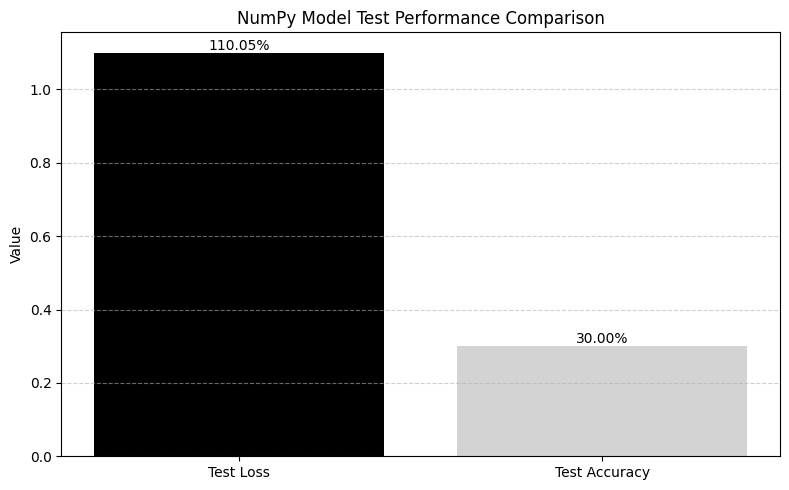

In [289]:
import matplotlib.pyplot as plt

metrics = ['Test Loss', 'Test Accuracy']
values = [test_loss, test_accuracy]

plt.figure(figsize=(8, 5))
# Use plt.bar to create a bar chart for the comparison
colors = ['black', 'lightgrey'] # Use black and grey colors
plt.bar(metrics, values, color=colors)
plt.ylabel('Value')
plt.title('NumPy Model Test Performance Comparison')
plt.ylim(bottom=0) # Set y-axis lower limit to 0

# Add text labels on top of the bars
for i, value in enumerate(values):
    # Corrected f-string: multiply by 100 before formatting, then use .2f
    plt.text(metrics[i], value, f'{value * 100:.2f}%', ha='center', va='bottom', fontsize=10, color='black')

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Test Accuracy Comparison Across Libraries

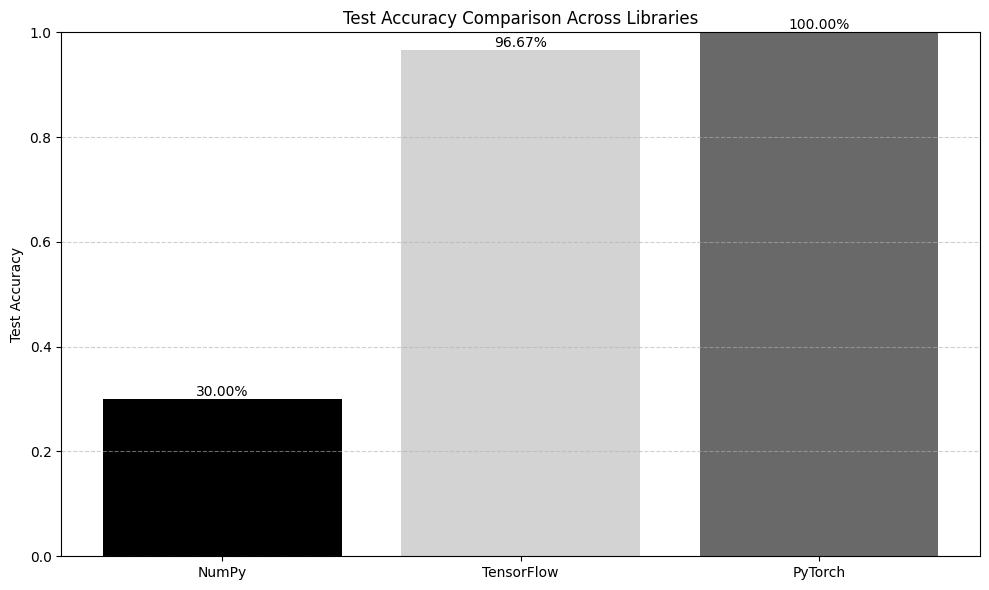

In [290]:
import matplotlib.pyplot as plt
import numpy as np

# Prepare data for Test Accuracy comparison
libraries = ['NumPy', 'TensorFlow', 'PyTorch']
accuracies = [test_accuracy, tf_accuracy, pt_accuracy]

plt.figure(figsize=(10, 6))
colors = ['black', 'lightgrey', 'dimgrey'] # Black, Light Grey, Dim Grey for consistent theme
plt.bar(libraries, accuracies, color=colors)
plt.ylabel('Test Accuracy')
plt.title('Test Accuracy Comparison Across Libraries')
plt.ylim(0, 1) # Accuracy ranges from 0 to 1

# Add text labels on top of the bars
for i, accuracy in enumerate(accuracies):
    plt.text(libraries[i], accuracy, f'{accuracy * 100:.2f}%', ha='center', va='bottom', fontsize=10, color='black')

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Test Loss Comparison Across Libraries

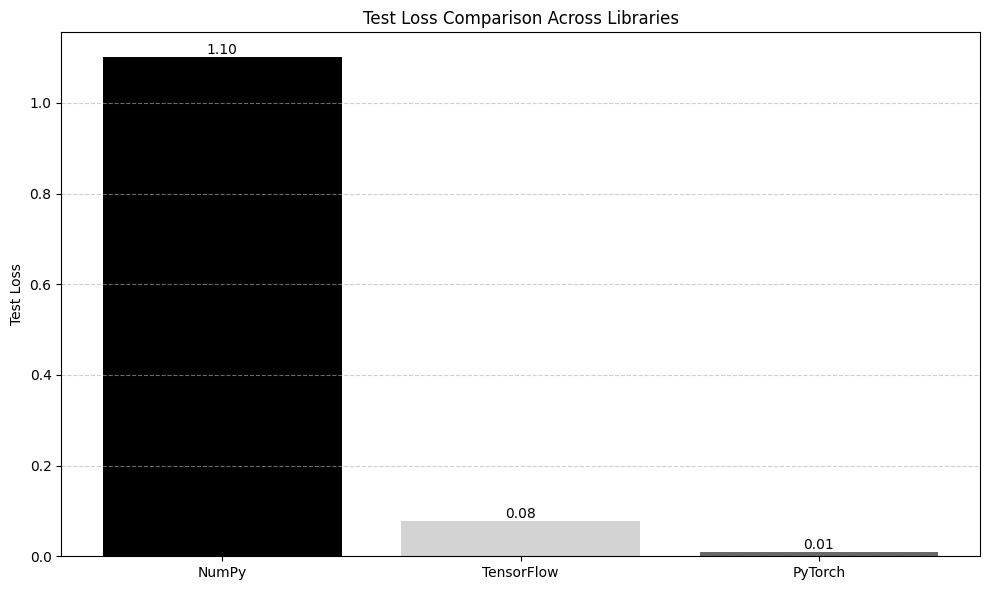

In [291]:
import matplotlib.pyplot as plt
import numpy as np

# Prepare data for Test Loss comparison
libraries = ['NumPy', 'TensorFlow', 'PyTorch']
losses = [test_loss, tf_loss, pt_test_loss]

plt.figure(figsize=(10, 6))
colors = ['black', 'lightgrey', 'dimgrey'] # Black, Light Grey, Dim Grey for consistent theme
plt.bar(libraries, losses, color=colors)
plt.ylabel('Test Loss')
plt.title('Test Loss Comparison Across Libraries')
plt.ylim(bottom=0) # Loss should be non-negative

# Add text labels on top of the bars
for i, loss in enumerate(losses):
    plt.text(libraries[i], loss, f'{loss:.2f}', ha='center', va='bottom', fontsize=10, color='black')

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()